Step 1: Dataset Understanding

In [2]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [3]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Estimated_Deliveries', ylabel='Count'>

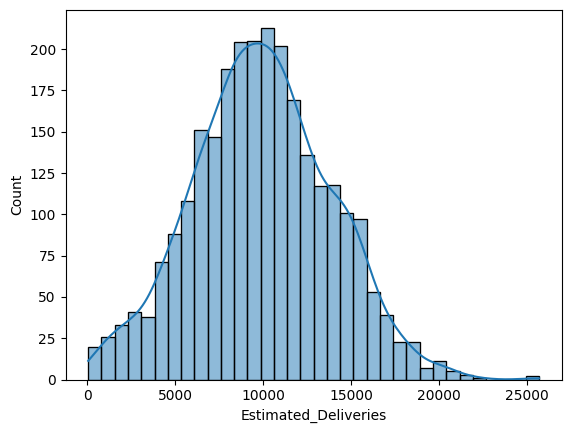

In [6]:
import seaborn as sns
sns.histplot(
    df["Estimated_Deliveries"],
    kde=True
)

<Axes: xlabel='Avg_Price_USD', ylabel='Count'>

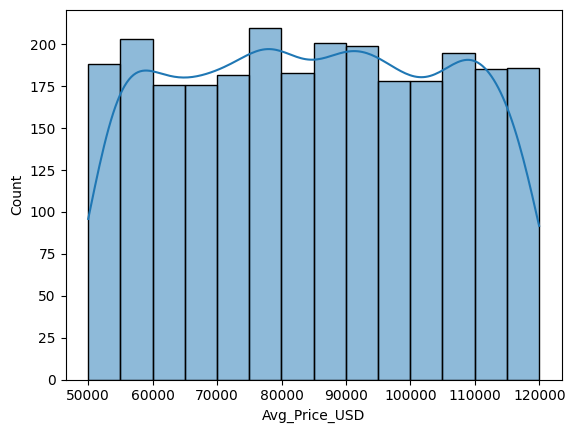

In [7]:
sns.histplot(
    df["Avg_Price_USD"],
    kde=True
)

<Axes: xlabel='Battery_Capacity_kWh', ylabel='Count'>

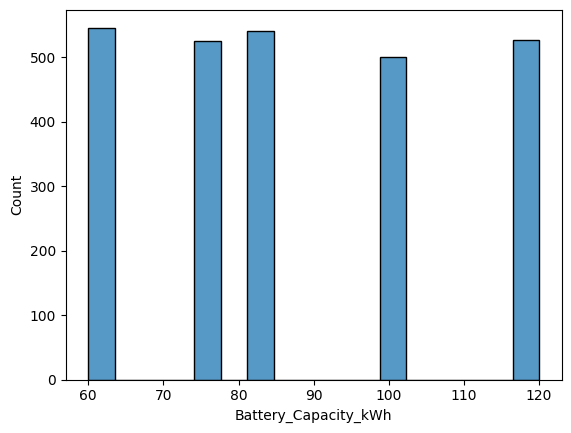

In [8]:
sns.histplot(
    df["Battery_Capacity_kWh"]
)

<Axes: >

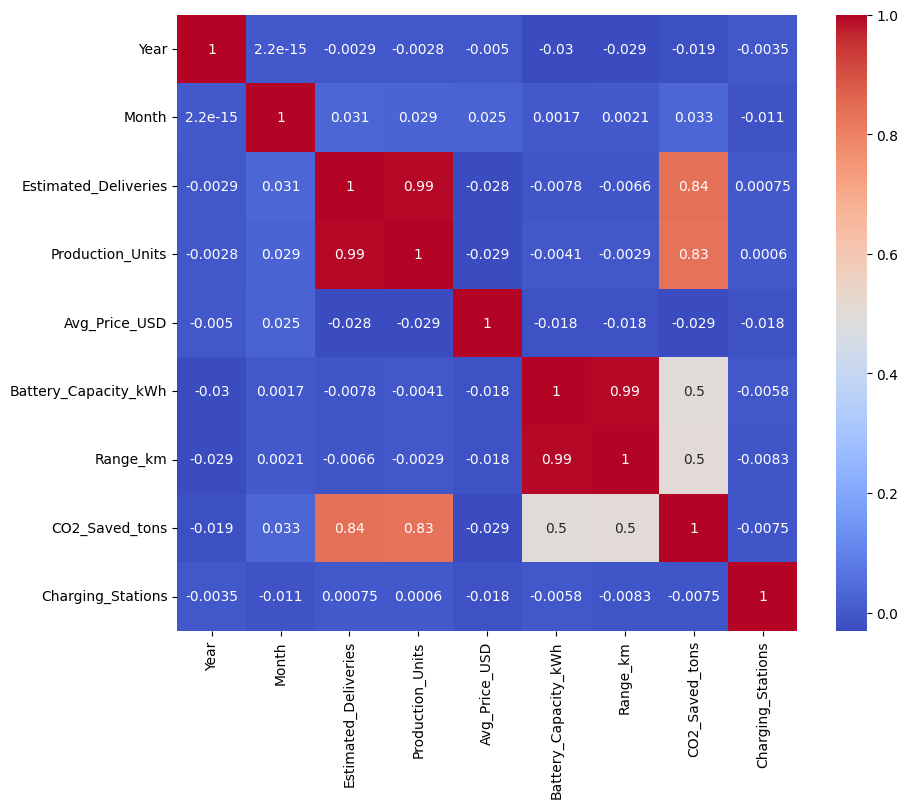

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

<Axes: xlabel='Date'>

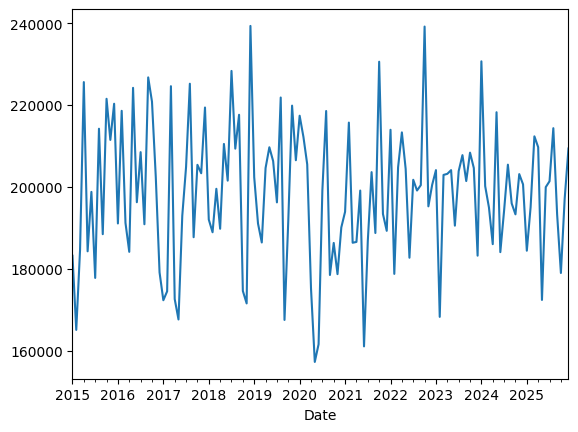

In [12]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) +
    "-" +
    df["Month"].astype(str)
)

monthly = df.groupby("Date")["Estimated_Deliveries"].sum()

monthly.plot()

<Axes: xlabel='Estimated_Deliveries', ylabel='Count'>

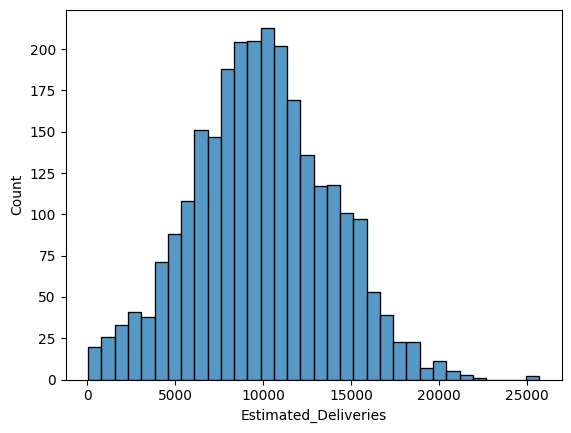

In [13]:
sns.histplot(df["Estimated_Deliveries"])

<Axes: xlabel='Avg_Price_USD', ylabel='Count'>

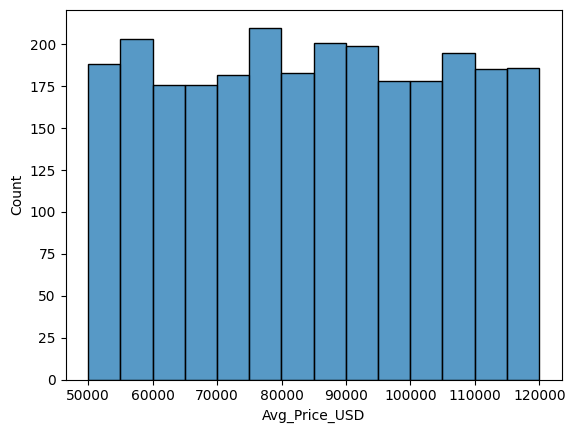

In [15]:
sns.histplot(df["Avg_Price_USD"])

<Axes: xlabel='Region', ylabel='Estimated_Deliveries'>

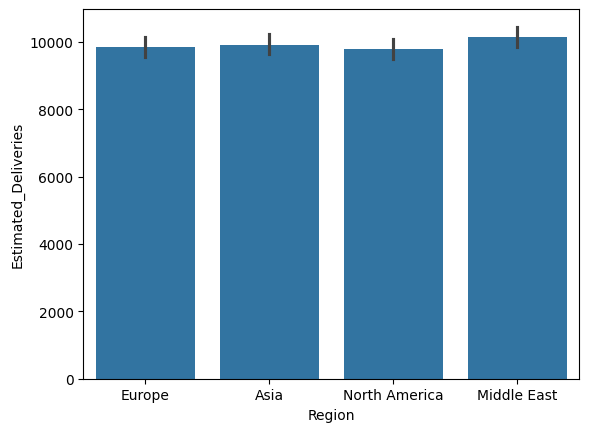

In [16]:
sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

In [18]:
df["Quarter"] = df["Date"].dt.quarter

df["Delivery_Rate"] = (
    df["Estimated_Deliveries"]
    /
    df["Production_Units"]
)

In [19]:
df["Price_per_km"] = (
    df["Avg_Price_USD"]
    /
    df["Range_km"]
)

In [20]:
import numpy as np

df["Month_sin"] = np.sin(
    2*np.pi*df["Month"]/12
)

df["Month_cos"] = np.cos(
    2*np.pi*df["Month"]/12
)

In [21]:
X = df.drop(
    ["Estimated_Deliveries","Date"],
    axis=1
)

y = df["Estimated_Deliveries"]

In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [25]:
cat_cols = [
    "Region",
    "Model",
    "Source_Type"
]

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

In [26]:
preprocessor = ColumnTransformer([
    ("num",StandardScaler(),num_cols),
    ("cat",OneHotEncoder(),cat_cols)
])

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_pred = lr_pipeline.predict(X_test)

print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2  :", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 108.84701192092766
RMSE: 153.88972029047076
R2  : 0.9984112714179098


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
rf_pred = rf_pipeline.predict(X_test)

print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2  :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 68.21081439393942
RMSE: 117.82715578482288
R2  : 0.9990686320755575


In [32]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
xgb_pred = xgb_pipeline.predict(X_test)

print("XGBoost Results")
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2  :", r2_score(y_test, xgb_pred))

XGBoost Results
MAE : 52.43155288696289
RMSE: 77.03876104354872
R2  : 0.9996018409729004


In [34]:
results = {
    "Linear Regression": {
        "R2": r2_score(y_test, lr_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, lr_pred))
    },
    "Random Forest": {
        "R2": r2_score(y_test, rf_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred))
    },
    "XGBoost": {
        "R2": r2_score(y_test, xgb_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred))
    }
}

for model, metrics in results.items():
    print(f"\n{model}")
    print(metrics)


Linear Regression
{'R2': 0.9984112714179098, 'RMSE': np.float64(153.88972029047076)}

Random Forest
{'R2': 0.9990686320755575, 'RMSE': np.float64(117.82715578482288)}

XGBoost
{'R2': 0.9996018409729004, 'RMSE': np.float64(77.03876104354872)}


In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5]
}

In [37]:
rf_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

In [38]:
grid_search = GridSearchCV(
    rf_tuned,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [39]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [40]:
print("Best CV Score:")
print(grid_search.best_score_)

Best CV Score:
0.9981081881642158


In [41]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("Tuned Random Forest")
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R2  :", r2_score(y_test, best_pred))

Tuned Random Forest
MAE : 68.75654294684693
RMSE: 120.0325547947236
R2  : 0.9990334405130775


In [47]:
monthly_sales = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


In [48]:
prophet_df = monthly_sales.rename(
    columns={
        "Date": "ds",
        "Estimated_Deliveries": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


In [49]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)

17:20:07 - cmdstanpy - INFO - Chain [1] start processing
17:20:07 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
future = model.make_future_dataframe(
    periods=12,
    freq="MS"
)

forecast = model.predict(future)

In [51]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(12)

,ds,yhat,yhat_lower,yhat_upper
132,2026-01-01,196486.908584,178167.850819,217430.724987
133,2026-02-01,191974.179450,173581.016273,210928.024826
134,2026-03-01,195309.159340,177191.494015,214332.524109
135,2026-04-01,197741.220347,179554.409799,216124.945992
136,2026-05-01,194862.563736,175954.736274,213023.463010
137,2026-06-01,190388.224883,171242.904721,209144.558371
138,2026-07-01,198694.769912,179612.592910,216390.897607
139,2026-08-01,210149.686564,191929.650598,228908.590203
140,2026-09-01,192711.050290,173335.802728,210683.703741
141,2026-10-01,204427.515383,186042.340090,223199.087056


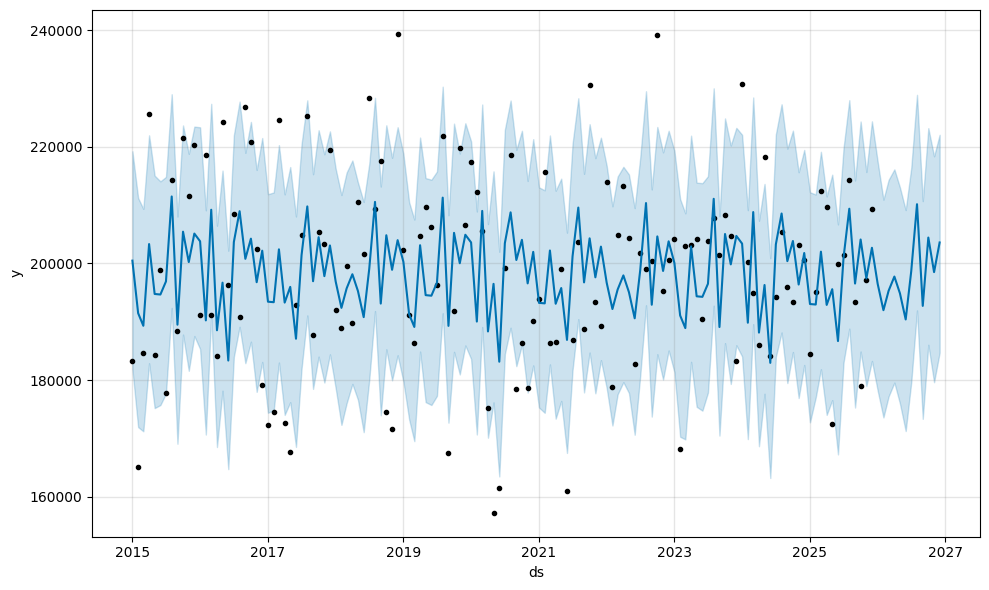

In [52]:
fig = model.plot(forecast)

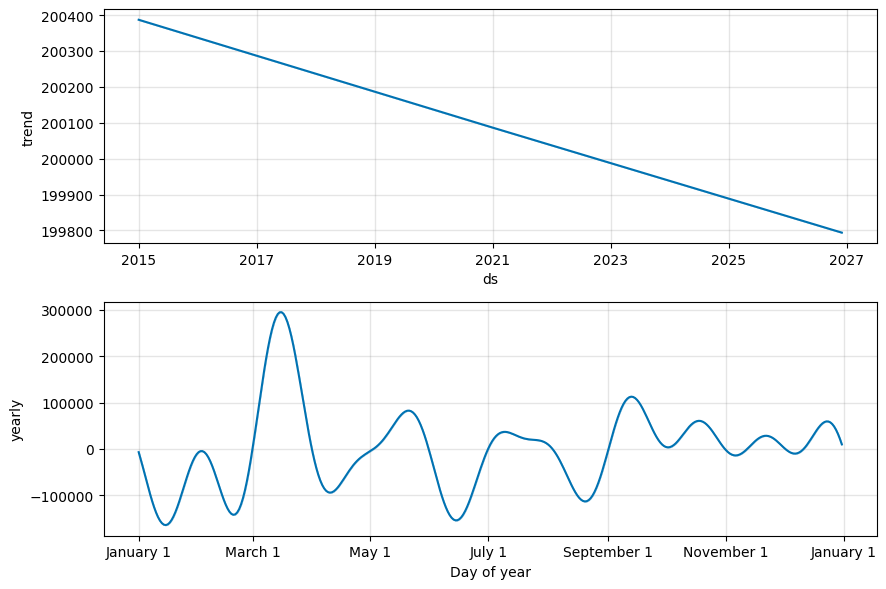

In [53]:
fig2 = model.plot_components(forecast)

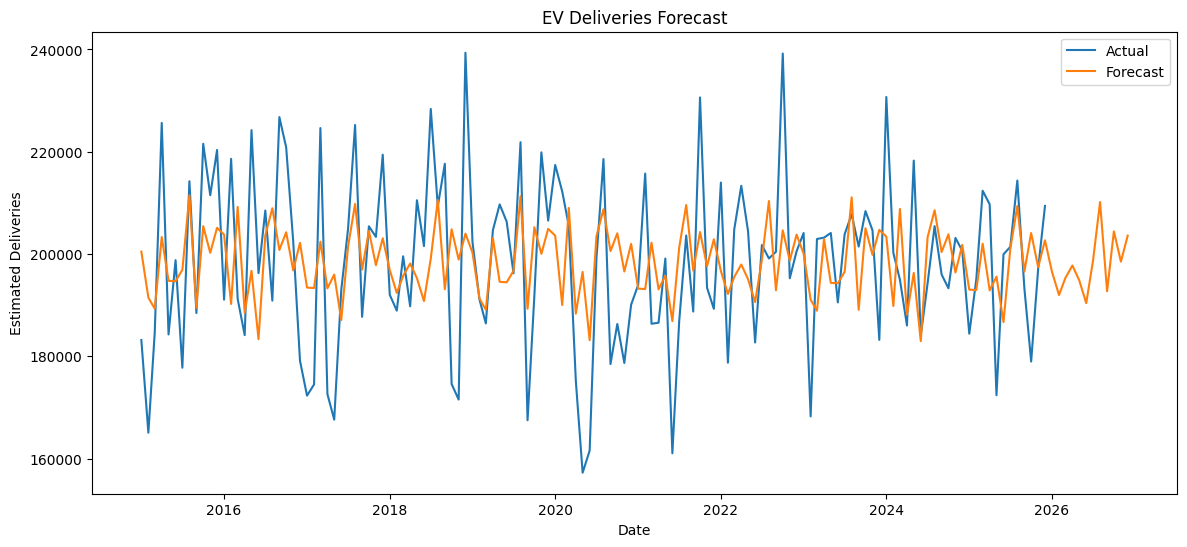

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    prophet_df["ds"],
    prophet_df["y"],
    label="Actual"
)

plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.title("EV Deliveries Forecast")

plt.legend()
plt.show()

In [55]:
train = prophet_df[:-12]
test = prophet_df[-12:]

In [56]:
model = Prophet()

model.fit(train)

17:21:08 - cmdstanpy - INFO - Chain [1] start processing
17:21:08 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
future = model.make_future_dataframe(
    periods=12,
    freq="MS"
)

forecast = model.predict(future)

In [58]:
predictions = forecast.tail(12)

predictions = predictions[
    ["ds","yhat"]
]

predictions.head()

,ds,yhat
120,2025-01-01,195137.718485
121,2025-02-01,192507.881767
122,2025-03-01,201645.572989
123,2025-04-01,190684.870078
124,2025-05-01,198665.758331


In [59]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test["y"],
    predictions["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        predictions["yhat"]
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 10796.748975508257
RMSE: 14151.609449433676


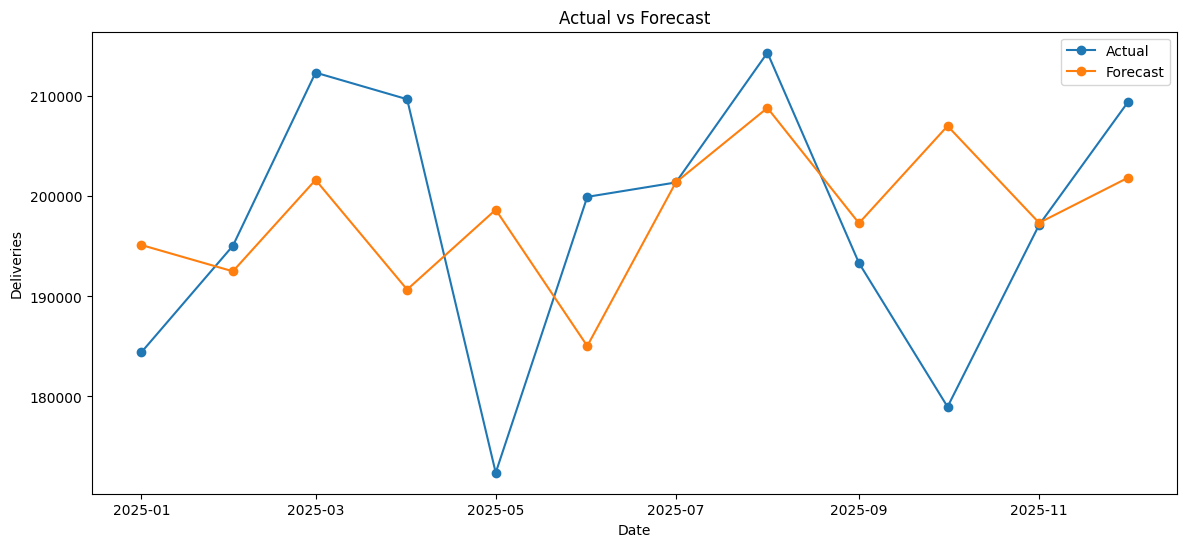

In [60]:
plt.figure(figsize=(14,6))

plt.plot(
    test["ds"],
    test["y"],
    marker="o",
    label="Actual"
)

plt.plot(
    predictions["ds"],
    predictions["yhat"],
    marker="o",
    label="Forecast"
)

plt.title("Actual vs Forecast")

plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.legend()

plt.show()